In [1]:
import os
import time
import math
import random
import joblib
import numpy as np
from pathlib import Path
from PIL import Image
from collections import Counter
from skimage.feature import hog
from skimage.transform import resize
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

# GPU / cuml imports
import cupy as cp
import cuml
from cuml.preprocessing import StandardScaler
from cuml.svm import LinearSVC

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed, dump, load

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
DATA_DIR = os.path.expanduser("~/Work/AI/face-prediction-model/Data") # adjust if different
POS_DIR_NAME = 'faces' # directory containing positive (face) images
NEG_DIR_NAME = 'backgrounds_clean' # directory containing negative (no-face) images

In [4]:
patch_size = (48, 48)
stride = 24
hog_params = dict(
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    orientations=9,
    block_norm='L2-Hys',
    feature_vector=True
)

# === PATCH EXTRACTION ===
def extract_patches_arr(img_arr, patch_size=(48,48), stride=24):
    """
    Extract patches from grayscale image array.
    Returns (N_patches, ph, pw) and list of (x,y,w,h).
    If too small, returns one resized patch.
    """
    H, W = img_arr.shape
    ph, pw = patch_size
    patches = []
    positions = []
    if H < 1 or W < 1:
        return np.zeros((0, ph, pw), dtype=img_arr.dtype), []
    y_iter_end = max(1, H - ph + 1)
    x_iter_end = max(1, W - pw + 1)
    for y in range(0, y_iter_end, stride):
        for x in range(0, x_iter_end, stride):
            patch = img_arr[y:y+ph, x:x+pw]
            if patch.shape != (ph, pw):
                patch = resize(patch, patch_size, preserve_range=True).astype(np.uint8)
            patches.append(patch)
            positions.append((x, y, pw, ph))
    if len(patches) == 0:
        cpatch = resize(img_arr, patch_size, preserve_range=True).astype(np.uint8)
        patches = [cpatch]
        positions = [(0, 0, pw, ph)]
    return np.stack(patches, axis=0), positions

In [5]:
class HOGPatchDataset(Dataset):
    """
    Returns (feats (L,D) numpy, labels (L,) numpy, positions, image_path)
    Label 1: from `pos_dir` (faces with subfolders)
    Label 0: from `neg_dir` (backgrounds)
    """
    def __init__(self, root_dir, pos_dir='faces', neg_dir='backgrounds_clean',
                 hog_params=hog_params, patch_size=patch_size, stride=stride,
                 parallel_hog_jobs=None):
        self.samples = []
        pos_root = os.path.join(root_dir, pos_dir)
        neg_root = os.path.join(root_dir, neg_dir)
        def collect_images(folder, label):
            for p in Path(folder).rglob("*"):
                if p.suffix.lower() in [".png", ".jpg", ".jpeg"]:
                    self.samples.append((str(p), label))
        collect_images(pos_root, 1)
        collect_images(neg_root, 0)
        self.hog_params = hog_params
        self.patch_size = patch_size
        self.stride = stride
        if parallel_hog_jobs is None:
            cpu_count = os.cpu_count() or 2
            self.parallel_hog_jobs = max(1, min(8, cpu_count - 1))
        else:
            self.parallel_hog_jobs = parallel_hog_jobs
        print(f"[HOGPatchDataset] Loaded {len(self.samples)} images "
              f"({pos_dir}: {sum(l==1 for _,l in self.samples)}, "
              f"{neg_dir}: {sum(l==0 for _,l in self.samples)})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p, label = self.samples[idx]
        try:
            img = Image.open(p).convert('L')
            arr = np.array(img)
        except Exception as e:
            print(f"Error loading {p}: {e}")
            return np.zeros((0,128), dtype=np.float32), np.zeros((0,), dtype=np.int32), [], p
        patches, positions = extract_patches_arr(arr, patch_size=self.patch_size, stride=self.stride)
        if len(patches) == 0:
            return np.zeros((0,128), dtype=np.float32), np.zeros((0,), dtype=np.int32), [], p
        n_jobs = self.parallel_hog_jobs
        feats = Parallel(n_jobs=n_jobs)(delayed(hog)(patch, **self.hog_params) for patch in patches)
        feats = np.stack(feats, axis=0).astype(np.float32)
        labels = np.ones((feats.shape[0],), dtype=np.int32) * int(label)
        return feats, labels, positions, p

# === SEQUENCE DATASET (PATCH-BASED FEATURE SET) ===
class PatchSequenceDataset(Dataset):
    """Dataset that loads HOG features from all images under root_dir (recursively)."""
    def __init__(self, root_dir, hog_params=hog_params, patch_size=patch_size, stride=stride):
        self.paths = [str(p) for p in Path(root_dir).rglob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
        self.hog_params = hog_params
        self.patch_size = patch_size
        self.stride = stride
        print(f"[PatchSequenceDataset] Found {len(self.paths)} images from {root_dir}")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        try:
            img = Image.open(p).convert('L')
            arr = np.array(img)
        except Exception as e:
            print(f"Error loading {p}: {e}")
            return torch.zeros((1,128)), torch.zeros((1,))
        patches, positions = extract_patches_arr(arr, patch_size=self.patch_size, stride=self.stride)
        feats = [hog(patch, **self.hog_params) for patch in patches]
        feats = np.stack(feats, axis=0).astype(np.float32)
        H, W = arr.shape
        cx, cy = W / 2.0, H / 2.0
        max_dist = math.sqrt(cx ** 2 + cy ** 2)
        labels = np.zeros(len(positions), dtype=np.float32)
        for i, (x, y, w, h) in enumerate(positions):
            px, py = x + w / 2, y + h / 2
            dist = math.sqrt((px - cx) ** 2 + (py - cy) ** 2)
            if (dist / max_dist) < 0.3:
                labels[i] = 1.0
        return torch.from_numpy(feats), torch.from_numpy(labels)

In [6]:
# cell 6

def collate_pad(batch):
    feats, labels = zip(*batch)
    lengths = [f.shape[0] for f in feats]
    feats_t = [torch.from_numpy(f) if isinstance(f, np.ndarray) else f for f in feats]
    labels_t = [torch.from_numpy(l) if isinstance(l, np.ndarray) else l for l in labels]
    feats_padded = pad_sequence(feats_t, batch_first=True)    # (B, Lmax, D)
    labels_padded = pad_sequence(labels_t, batch_first=True)  # (B, Lmax)
    maxL = feats_padded.shape[1]
    mask = (torch.arange(maxL).unsqueeze(0) < torch.tensor(lengths).unsqueeze(1))
    mask = mask.to(torch.bool)
    return feats_padded, labels_padded, mask


# instantiate datasets
seq_dataset = PatchSequenceDataset(DATA_DIR, hog_params, patch_size, stride)
print('Sequence dataset images:', len(seq_dataset))

# deterministic split
SEED = 42
torch.manual_seed(SEED)
train_ratio = 0.8
n = len(seq_dataset)
train_size = int(train_ratio * n)
val_size = n - train_size
train_dataset, val_dataset = random_split(seq_dataset, [train_size, val_size])

BATCH_SIZE = 16

print("Extracting and saving HOG features (with checkpointing)...")

# instantiate the dataset with fewer parallel workers to save memory
dataset = HOGPatchDataset(
    DATA_DIR,
    pos_dir=POS_DIR_NAME,
    neg_dir=NEG_DIR_NAME,
    hog_params=hog_params,
    patch_size=patch_size,
    stride=stride,
    parallel_hog_jobs=2
)

# incremental save configuration
output_path = Path("hog_features_partial.joblib")
if output_path.exists():
    X, y = load(output_path)
    print(f"Resuming from {len(y)} samples in partial checkpoint.")
else:
    X, y = [], []

save_every = 1000  # save every N images

# extract and save incrementally
for i, (feats, labels, _, _) in enumerate(tqdm(dataset, desc="Extracting HOG features")):
    X.append(feats)
    y.append(labels)

    if (i + 1) % save_every == 0:
        Xcat = np.concatenate(X)
        ycat = np.concatenate(y)
        dump((Xcat, ycat), output_path)
        print(f"[checkpoint] saved {len(ycat)} samples at {i+1} images")
        X, y = [], []  # free memory

# final save
if X:
    Xcat = np.concatenate(X)
    ycat = np.concatenate(y)
    if output_path.exists():
        Xprev, yprev = load(output_path)
        Xcat = np.concatenate([Xprev, Xcat])
        ycat = np.concatenate([yprev, ycat])
    dump((Xcat, ycat), "hog_features.joblib")
    print("Final HOG features saved -> hog_features.joblib")

# create dataloaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_pad, pin_memory=True, num_workers=4
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_pad, pin_memory=True, num_workers=4
)

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

# sanity check for label distribution
cnt = {0: 0, 1: 0}
for i in range(min(200, len(train_dataset))):
    feats, labels = train_dataset[i]
    vals = labels.numpy().ravel().astype(int)
    cnt[0] += int((vals == 0).sum())
    cnt[1] += int((vals == 1).sum())
print('token-level sample counts:', cnt)


[PatchSequenceDataset] Found 114542 images from /home/parasite/Work/AI/face-prediction-model/Data
Sequence dataset images: 114542
Extracting and saving HOG features (with checkpointing)...
[HOGPatchDataset] Loaded 114542 images (faces: 57756, backgrounds_clean: 56786)


Extracting HOG features:   1%|          | 1008/114542 [00:13<25:05, 75.39it/s]

[checkpoint] saved 1000 samples at 1000 images


Extracting HOG features:   2%|▏         | 2012/114542 [00:26<25:13, 74.33it/s]

[checkpoint] saved 1000 samples at 2000 images


...

[checkpoint] saved 107648 samples at 113000 images


Extracting HOG features: 100%|█████████▉| 114003/114542 [1:28:13<01:02,  8.68it/s]

[checkpoint] saved 109548 samples at 114000 images


Extracting HOG features: 100%|██████████| 114542/114542 [1:28:56<00:00, 21.47it/s]


Final HOG features saved -> hog_features.joblib
Train size: 91633 | Val size: 22909
token-level sample counts: {0: 7473, 1: 1777}


In [13]:
EMBED_DIM = 128
NUM_HEADS = 4
NUM_LAYERS = 2
FFN_DIM = 256
DROPOUT = 0.2
LR = 1e-3
WEIGHT_DECAY = 1e-4
LR_SCHED_STEP = 10
LR_SCHED_GAMMA = 0.9
EPOCHS = 10

In [9]:
# cell 8 — Fixed for cuML LinearSVC (GPU)

svm_ds = HOGPatchDataset(
    DATA_DIR,
    pos_dir=POS_DIR_NAME,
    neg_dir=NEG_DIR_NAME,
    hog_params=hog_params,
    patch_size=patch_size,
    stride=stride,
    parallel_hog_jobs=2  # limit threads to prevent memory blow-up
)
print('SVM dataset images:', len(svm_ds))

MAX_PATCHES = 100000
feats_list, labels_list = [], []
count = 0

for i in tqdm(range(len(svm_ds)), desc='Collecting patches for SVM'):
    feats, labs, _, _ = svm_ds[i]
    if feats.shape[0] == 0:
        continue
    feats_list.append(feats)
    labels_list.append(labs)
    count += feats.shape[0]
    if count >= MAX_PATCHES:
        break

if len(feats_list) == 0:
    raise RuntimeError('No patches collected for SVM. Check your DATA_DIR and subfolders.')

# concatenate and shuffle
X = np.concatenate(feats_list, axis=0).astype(np.float32)
y = np.concatenate(labels_list, axis=0).astype(np.int32)
print('Collected patch features shape:', X.shape)

idxs = np.arange(len(X))
np.random.seed(42)
np.random.shuffle(idxs)
X = X[idxs]
y = y[idxs]

# split train/test
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# move data to GPU
Xtr_cp = cp.asarray(Xtr)
Xte_cp = cp.asarray(Xte)
ytr_cp = cp.asarray(ytr).astype(cp.int32)
yte_cp = cp.asarray(yte).astype(cp.int32)

# fit scaler on GPU
scaler = StandardScaler()
scaler.fit(Xtr_cp)
Xtr_s_cp = scaler.transform(Xtr_cp)
Xte_s_cp = scaler.transform(Xte_cp)

# === cuML LinearSVC (GPU) ===
svm = LinearSVC(class_weight='balanced', max_iter=20000)  # removed random_state
svm.fit(Xtr_s_cp, ytr_cp)

# inference and evaluation
y_pred_cp = svm.predict(Xte_s_cp)
y_pred = cp.asnumpy(y_pred_cp).astype(np.int32)

print(classification_report(yte, y_pred))
print('Confusion matrix:\n', confusion_matrix(yte, y_pred))
print(f'Accuracy: {accuracy_score(yte, y_pred):.4f}')

# save GPU-trained models
joblib.dump(svm, 'hog_svm_linear_gpu.joblib')
joblib.dump(scaler, 'hog_svm_scaler_gpu.joblib')
print('Saved cuML SVM and scaler to disk.')


[HOGPatchDataset] Loaded 114542 images (faces: 57756, backgrounds_clean: 56786)
SVM dataset images: 114542


Collected patch features shape: (100341, 900)
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      8517
           1       0.98      0.96      0.97     11552

    accuracy                           0.97     20069
   macro avg       0.96      0.97      0.97     20069
weighted avg       0.97      0.97      0.97     20069

Confusion matrix:
 [[ 8282   235]
 [  439 11113]]
Accuracy: 0.9664
Saved cuML SVM and scaler to disk.


In [ ]:
# cell 9

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        L = x.size(1)
        return x + self.pe[:, :L, :]


class TokenAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn_proj = nn.Linear(d_model, 1)

    def forward(self, z, mask):
        scores = self.attn_proj(z).squeeze(-1)
        scores = scores.masked_fill(~mask, float('-inf'))
        weights = torch.softmax(scores, dim=1)
        return weights


class TransformerWithTokenAttention(nn.Module):
    def __init__(self, feat_dim, d_model=EMBED_DIM, nhead=NUM_HEADS, num_layers=NUM_LAYERS,
                 dim_feedforward=FFN_DIM, dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Linear(feat_dim, d_model)
        self.pos = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.token_attn = TokenAttention(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x, mask):
        z = self.input_proj(x)
        z = self.pos(z)
        src_key_padding_mask = ~mask if mask is not None else None
        out = self.encoder(z, src_key_padding_mask=src_key_padding_mask)
        logits = self.head(out).squeeze(-1)
        attn_weights = self.token_attn(out, mask)
        return logits, attn_weights


sample_batch = next(iter(train_loader))
feat_dim = sample_batch[0].shape[-1]
print('Inferred feat_dim:', feat_dim)

detector = TransformerWithTokenAttention(feat_dim).to(device)
criterion = nn.BCEWithLogitsLoss(reduction='none')
optimizer = optim.AdamW(detector.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_SCHED_STEP, gamma=LR_SCHED_GAMMA)


Inferred feat_dim: 900


In [14]:
# cell 10
# optional: replace StepLR with ReduceLROnPlateau for smoother convergence
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2, verbose=True)

metrics = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

best_val_loss = float('inf')
patience = 3          # stop if no improvement for 3 epochs
no_improve_epochs = 0

for epoch in range(1, EPOCHS + 1):
    detector.train()
    t0 = time.time()
    train_loss_accum = 0.0
    train_tokens = 0

    # === TRAIN LOOP ===
    for feats, labels, mask in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        feats = feats.to(device).float()
        labels = labels.to(device).float()
        mask = mask.to(device)
        optimizer.zero_grad()
        logits, _ = detector(feats, mask)
        loss_all = criterion(logits, labels)
        loss_masked = (loss_all * mask.float()).sum() / max(1.0, mask.float().sum())
        loss_masked.backward()
        optimizer.step()
        train_loss_accum += loss_masked.item() * mask.float().sum().item()
        train_tokens += mask.float().sum().item()

    # === VALIDATION LOOP ===
    detector.eval()
    all_preds, all_trues = [], []
    val_loss_accum, val_tokens = 0.0, 0

    with torch.no_grad():
        for feats, labels, mask in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]"):
            feats = feats.to(device).float()
            labels = labels.to(device).float()
            mask = mask.to(device)
            logits, _ = detector(feats, mask)
            loss_all = criterion(logits, labels)
            val_loss_accum += (loss_all * mask.float()).sum().item()
            val_tokens += mask.float().sum().item()

            probs = torch.sigmoid(logits)
            for b in range(probs.shape[0]):
                Lb = int(mask[b].sum().item())
                if Lb == 0:
                    continue
                pred_vals = (probs[b, :Lb] > 0.5).long().cpu().numpy().tolist()
                true_vals = labels[b, :Lb].long().cpu().numpy().tolist()
                all_preds.extend(pred_vals)
                all_trues.extend(true_vals)

    # === METRICS ===
    val_loss = val_loss_accum / max(1, val_tokens)
    if len(all_trues) == 0:
        val_acc, val_f1 = 0.0, 0.0
    else:
        val_acc = accuracy_score(all_trues, all_preds)
        try:
            val_f1 = f1_score(all_trues, all_preds, average='binary')
        except ValueError:
            val_f1 = 0.0

    metrics['epoch'].append(epoch)
    metrics['train_loss'].append(train_loss_accum / max(1, train_tokens))
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)
    metrics['val_f1'].append(val_f1)

    # update LR scheduler (adaptive)
    scheduler.step(val_loss)

    # === EARLY STOPPING ===
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        no_improve_epochs = 0
        torch.save(detector.state_dict(), 'transformer_detector_best.pth')
        print(f"New best model saved at epoch {epoch} (Val Loss: {val_loss:.6f})")
    else:
        no_improve_epochs += 1
        print(f"No improvement ({no_improve_epochs}/{patience})")
        if no_improve_epochs >= patience:
            print(f"Early stopping triggered at epoch {epoch}. Best Val Loss: {best_val_loss:.6f}")
            break

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss_accum / max(1, train_tokens):.6f} | "
          f"Val Loss: {val_loss:.6f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | "
          f"time: {time.time()-t0:.1f}s")

/home/parasite/.pyenv/versions/3.10.13/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/10 [val]: 100%|██████████| 1432/1432 [03:57<00:00,  6.02it/s]


New best model saved at epoch 1 (Val Loss: 0.049541)
Epoch 1/10 | Train Loss: 0.049368 | Val Loss: 0.049541 | Val Acc: 0.9795 | Val F1: 0.9453 | time: 1181.3s


Epoch 2/10 [val]: 100%|██████████| 1432/1432 [03:58<00:00,  6.01it/s]


New best model saved at epoch 2 (Val Loss: 0.048026)
Epoch 2/10 | Train Loss: 0.047793 | Val Loss: 0.048026 | Val Acc: 0.9808 | Val F1: 0.9492 | time: 1178.9s


Epoch 3/10 [val]: 100%|██████████| 1432/1432 [03:58<00:00,  6.02it/s]


...

No improvement (1/3)
Epoch 7/10 | Train Loss: 0.042219 | Val Loss: 0.045530 | Val Acc: 0.9816 | Val F1: 0.9512 | time: 1187.0s


Epoch 8/10 [val]: 100%|██████████| 1432/1432 [03:57<00:00,  6.03it/s]


No improvement (2/3)
Epoch 8/10 | Train Loss: 0.040796 | Val Loss: 0.045598 | Val Acc: 0.9813 | Val F1: 0.9510 | time: 1180.6s


Epoch 9/10 [val]: 100%|██████████| 1432/1432 [03:57<00:00,  6.04it/s]


No improvement (3/3)
Early stopping triggered at epoch 9. Best Val Loss: 0.043832


In [15]:
# cell 11

def non_max_suppression(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes).astype(float)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = np.argsort(scores)[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1 + 1)
        h = np.maximum(0.0, yy2 - yy1 + 1)
        inter = w * h
        iou = inter / (areas[i] + areas[order[1:]] - inter)
        inds = np.where(iou <= iou_threshold)[0]
        order = order[inds + 1]
    return keep


# load the GPU-trained SVM & scaler
try:
    svm = joblib.load('hog_svm_linear_gpu.joblib')
    scaler = joblib.load('hog_svm_scaler_gpu.joblib')
    print("Loaded GPU SVM and scaler from disk.")
except Exception as e:
    print("Couldn't load GPU SVM/scaler from disk; ensure you trained and saved them. Error:", e)
    # fallback: CPU models
    try:
        svm = joblib.load('hog_svm_linear.joblib')
        scaler = joblib.load('hog_svm_scaler.joblib')
        print("Loaded CPU SVM/scaler fallback.")
    except Exception:
        svm = None
        scaler = None


def detect_and_crop(image_path, svm, scaler, transformer=None, top_k=None, score_thresh=0.5,
                    nms_iou=0.3, scales=[1.0, 1.25, 1.5, 0.8]):
    """
    Multi-scale sliding-window detector using HOG+SVM, with optional transformer refinement.
    Returns list of (bbox (x1,y1,x2,y2), score, crop_rgb_array)
    """
    img_gray = Image.open(image_path).convert('L')
    arr_gray = np.array(img_gray)
    img_color = Image.open(image_path).convert('RGB')
    arr_color = np.array(img_color)

    all_boxes, all_scores = [], []
    H0, W0 = arr_gray.shape

    if svm is None or scaler is None:
        raise RuntimeError("SVM or scaler not loaded. Train or load GPU models first.")

    for scale in scales:
        Hs = max(1, int(round(H0 * scale)))
        Ws = max(1, int(round(W0 * scale)))
        if Hs < patch_size[0] or Ws < patch_size[1]:
            continue
        scaled = resize(arr_gray, (Hs, Ws), preserve_range=True).astype(np.uint8)

        patches, positions = extract_patches_arr(scaled, patch_size=patch_size, stride=stride)
        if patches.shape[0] == 0:
            continue

        feats = np.stack([hog(p, **hog_params) for p in patches], axis=0).astype(np.float32)
        feats_cp = cp.asarray(feats)

        try:
            feats_s_cp = scaler.transform(feats_cp)
        except Exception:
            feats_s_cp = cp.asarray(feats.astype(np.float32))

        try:
            scores_cp = svm.decision_function(feats_s_cp)
        except Exception:
            preds_cp = svm.predict(feats_s_cp)
            scores_cp = preds_cp.astype(cp.float32)

        scores = cp.asnumpy(scores_cp).ravel()
        probs = 1.0 / (1.0 + np.exp(-scores))

        for (x, y, w, h), p in zip(positions, probs):
            if p >= score_thresh and not np.isnan(p):
                x1 = int(round(x / scale))
                y1 = int(round(y / scale))
                x2 = int(round((x + w - 1) / scale))
                y2 = int(round((y + h - 1) / scale))
                x1 = max(0, min(x1, W0 - 1))
                y1 = max(0, min(y1, H0 - 1))
                x2 = max(0, min(x2, W0 - 1))
                y2 = max(0, min(y2, H0 - 1))
                if x2 <= x1 or y2 <= y1:
                    continue
                all_boxes.append([x1, y1, x2, y2])
                all_scores.append(float(p))

    if len(all_boxes) == 0:
        return []

    keep_idx = non_max_suppression(all_boxes, all_scores, iou_threshold=nms_iou)
    final_boxes = [all_boxes[i] for i in keep_idx]
    final_scores = [all_scores[i] for i in keep_idx]

    # optional transformer refinement
    if transformer is not None and len(final_boxes) > 0:
        kept_feats = []
        kept_boxes = []
        for (x1, y1, x2, y2) in final_boxes:
            crop_gray = arr_gray[y1:y2 + 1, x1:x2 + 1]
            crop_resized = resize(crop_gray, patch_size, preserve_range=True).astype(np.uint8)
            f = hog(crop_resized, **hog_params)
            kept_feats.append(f)
            kept_boxes.append((x1, y1, x2, y2))

        if len(kept_feats) > 0:
            xf = torch.tensor(np.stack(kept_feats, axis=0)).unsqueeze(0).to(device).float()
            mask = torch.ones((1, xf.shape[1]), dtype=torch.bool).to(device)
            transformer.eval()
            with torch.no_grad():
                logits, _ = transformer(xf, mask)
                probs_t = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            final_scores = [float(probs_t[i]) for i in range(len(final_scores))]

    crops = []
    for (x1, y1, x2, y2), s in zip(final_boxes, final_scores):
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        crop_rgb = arr_color[y1:y2 + 1, x1:x2 + 1].copy()
        crops.append(((x1, y1, x2, y2), float(s), crop_rgb))

    if top_k is not None and len(crops) > 0:
        crops = sorted(crops, key=lambda x: x[1], reverse=True)[:top_k]

    return crops


Loaded GPU SVM and scaler from disk.


Saved transformer state_dict -> transformer_detector.pth


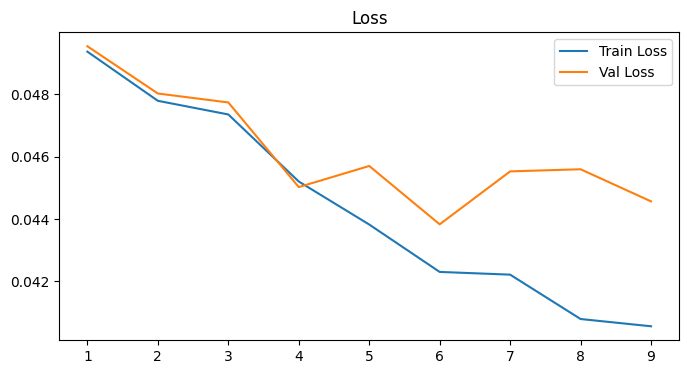

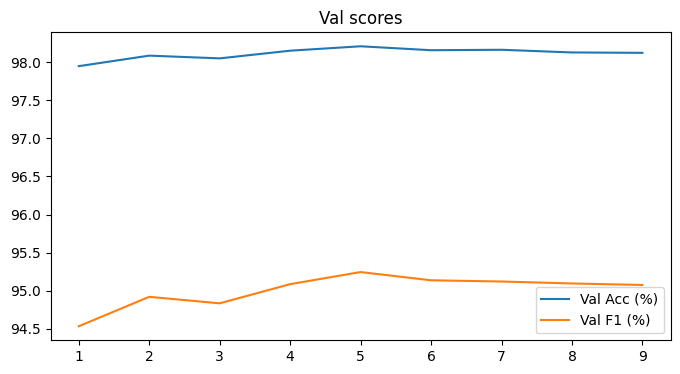

Running example detection on ./test_data/smile.png
Found 22 crops
0 (144, 240, 175, 271) 0.9999181032180786
1 (112, 224, 143, 255) 0.9999567270278931
2 (256, 144, 287, 175) 0.999946117401123
3 (211, 250, 249, 287) 0.9999171495437622
4 (58, 77, 95, 114) 0.9999115467071533
5 (240, 72, 287, 119) 0.9997972846031189
6 (230, 211, 268, 249) 0.9999105930328369
7 (192, 307, 230, 345) 0.9999524354934692
8 (144, 48, 191, 95) 0.9999494552612305
9 (115, 269, 153, 306) 0.9998944997787476
10 (120, 240, 179, 299) 0.998448371887207
11 (112, 304, 143, 335) 0.9998262524604797
12 (120, 180, 179, 239) 0.9983945488929749
13 (256, 224, 287, 255) 0.9998865127563477
14 (150, 300, 209, 359) 0.9998822212219238
15 (96, 336, 143, 383) 0.999904990196228
16 (192, 58, 230, 95) 0.9975027441978455
17 (269, 192, 306, 230) 0.998785674571991
18 (176, 112, 207, 143) 0.9999172687530518
19 (216, 168, 263, 215) 0.9999086856842041
20 (96, 173, 134, 210) 0.9999496936798096
21 (176, 224, 207, 255) 0.9999508857727051
Saved exampl

In [16]:
# cell 12

torch.save(detector.state_dict(), 'transformer_detector.pth')
print('Saved transformer state_dict -> transformer_detector.pth')

try:
    import pandas as pd
    df = pd.DataFrame(metrics)
    plt.figure(figsize=(8,4))
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
    plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Loss'); plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(df['epoch'], df['val_acc'] * 100, label='Val Acc (%)')
    plt.plot(df['epoch'], df['val_f1'] * 100, label='Val F1 (%)')
    plt.legend(); plt.title('Val scores'); plt.show()

except Exception:
    print('No metrics to plot or pandas not available.')


# === Example usage ===
sample_path = './test_data/smile.png'
face_dir = os.path.join(DATA_DIR, POS_DIR_NAME)

if os.path.isdir(face_dir):
    for fn in os.listdir(face_dir):
        if fn.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_path = os.path.join(face_dir, fn)
            break

if sample_path is not None:
    print('Running example detection on', sample_path)
    crops = detect_and_crop(sample_path, svm, scaler, transformer=detector, score_thresh=0.5)
    print('Found', len(crops), 'crops')
    for i, (bbox, score, crop) in enumerate(crops):
        print(i, bbox, score)
        Image.fromarray(crop).save(f'crop_example_{i}.png')
    print('Saved example crops to disk (crop_example_*.png)')
else:
    print('No sample image found for quick demo. Place images under', face_dir)


In [20]:
# === Example usage ===
sample_path = './test_data/sup.png'
face_dir = os.path.join(DATA_DIR, POS_DIR_NAME)

if os.path.isdir(face_dir):
    for fn in os.listdir(face_dir):
        if fn.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_path = os.path.join(face_dir, fn)
            break

if sample_path is not None:
    print('Running example detection on', sample_path)
    crops = detect_and_crop(sample_path, svm, scaler, transformer=detector, score_thresh=0.5)
    print('Found', len(crops), 'crops')
    for i, (bbox, score, crop) in enumerate(crops):
        print(i, bbox, score)
        Image.fromarray(crop).save(f'crop_example_{i}.png')
    print('Saved example crops to disk (crop_example_*.png)')
else:
    print('No sample image found for quick demo. Place images under', face_dir)

Running example detection on ./test_data/sup.png
Found 116 crops
0 (64, 48, 95, 79) 0.31597861647605896
1 (64, 464, 95, 495) 0.2992967665195465
2 (420, 510, 479, 569) 0.3193606436252594
3 (64, 400, 95, 431) 0.28477659821510315
4 (336, 448, 367, 479) 0.3117764890193939
5 (64, 528, 95, 559) 0.283903568983078
6 (456, 312, 503, 359) 0.2973366677761078
7 (368, 208, 399, 239) 0.2876393496990204
8 (432, 528, 463, 559) 0.28589192032814026
9 (64, 432, 95, 463) 0.29535964131355286
10 (390, 330, 449, 389) 0.28558939695358276
11 (480, 211, 518, 249) 0.303173303604126
12 (512, 352, 543, 383) 0.2912769913673401
13 (496, 416, 527, 447) 0.2649986445903778
14 (464, 416, 495, 447) 0.2873592674732208
15 (160, 368, 191, 399) 0.27473193407058716
16 (0, 512, 31, 543) 0.26756569743156433
17 (77, 307, 114, 345) 0.2666671872138977
18 (384, 326, 422, 364) 0.27646294236183167
19 (330, 360, 389, 419) 0.28106027841567993
20 (480, 480, 539, 539) 0.2867316007614136
21 (432, 256, 463, 287) 0.2552682161331177
22 (640,